In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt 
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Define the ticker symbol for the Shanghai Composite Index
ticker = '000001.SS'

# Define the date range
start_date = '2014-01-01'
end_date = '2024-01-01'

# Download the full dataset sourced from yahoo finance
data = yf.download(ticker, start=start_date, end=end_date)

print(pd.concat([data.head(1), data.tail(1)]))


[*********************100%%**********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2014-01-02  2112.125977  2113.110107  2101.016113  2109.386963  2109.386963   
2023-12-29  2950.836914  2975.031982  2950.017090  2974.935059  2974.935059   

            Volume  
Date                
2014-01-02   68500  
2023-12-29  290700  


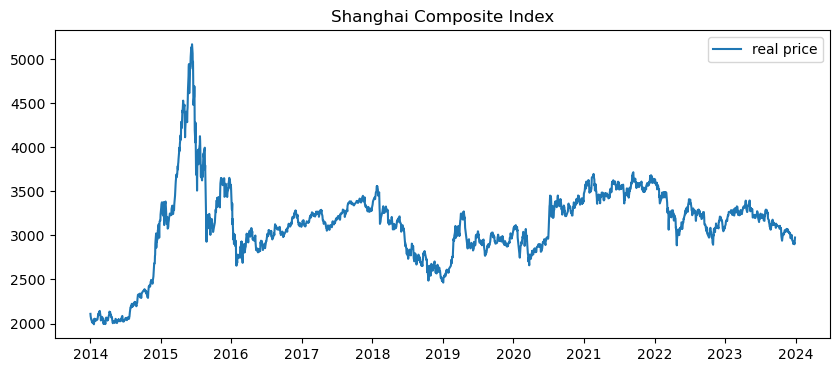

In [3]:
# Plot historical price data
plt.figure(figsize=(10,4))
plt.title('Shanghai Composite Index')
plt.plot(data['Close'], label='real price')
plt.legend()
plt.show()

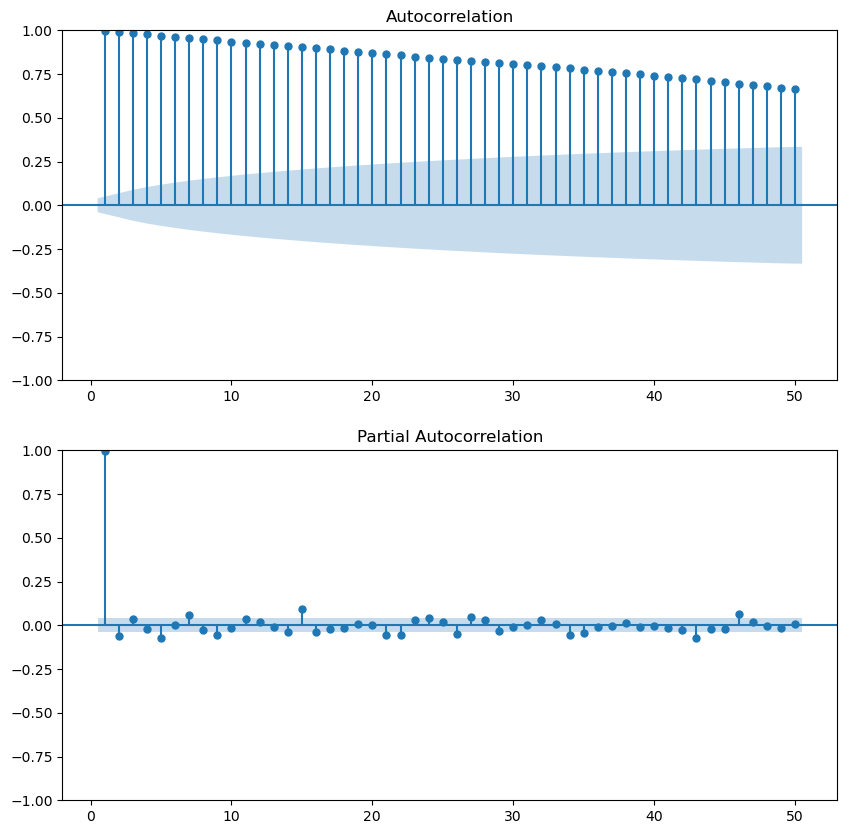

In [5]:
# Define a function for ACF and PACF plots
def plot_acf_pacf(data):
    # Create figure
    fig, ax = plt.subplots(2, figsize=(10,10))
    # Make ACF plot
    plot_acf(data, lags=50, zero=False, ax=ax[0])
    # Make PACF plot with Yule-Walker Method
    plot_pacf(data, lags=50, zero=False, method='ywm', ax=ax[1])
    # Show plots
    return plt.show()

# Plot the ACF and PACF for original data
plot_acf_pacf(data['Close'])

In [7]:
# Extract close price as our target data, denoted by X
X = data.Close

# Perform the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary
result = adfuller(X)
# Print the test statistic - a more negative value indicates a higher likelihood of stationarity
print('Dickey-Fuller Statistic: %f' % result[0])
# Print the p-value - a lower value (typically < 0.05) means we can reject the null hypothesis of non-stationarity
print('p-value: %f' % result[1])
# Print the critical values at different confidence levels (1%, 5%, and 10%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check if the time series is stationary
result_kpss = kpss(X, regression='c')
# Print the KPSS test statistic - a higher value indicates a higher likelihood of non-stationarity
print('KPSS Statistic: %f' % result_kpss[0])
# Print the p-value - a higher value (typically > 0.05) means we cannot reject the null hypothesis of stationarity
print('p-value: %f' % result_kpss[1])
# Print the critical values at different confidence levels (10%, 5%, 2.5%, and 1%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

Dickey-Fuller Statistic: -3.124732
p-value: 0.024776
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.802910
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


In [8]:
# Differencing data
stationary = X.diff(1)
stationary.dropna(axis=0, inplace=True)

# Perform Dicky-Fuller test
result_new = adfuller(stationary)
print('Adata Statistic: %f' % result_new[0])
print('p-value: %f' % result_new[1])
print('Critical Values:')
for key, value in result_new[4].items():
    print('\t%s: %.3f' % (key, value))
    
# Perform KPSS test
result_kpss_new = kpss(stationary, regression='c')
print('KPSS Statistic: %f' % result_kpss_new[0])
print('p-value: %f' % result_kpss_new[1])
print('Critical Values:')
for key, value in result_kpss_new[3].items():
    print('\t%s: %.3f' % (key, value))

Adata Statistic: -9.738395
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.101244
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


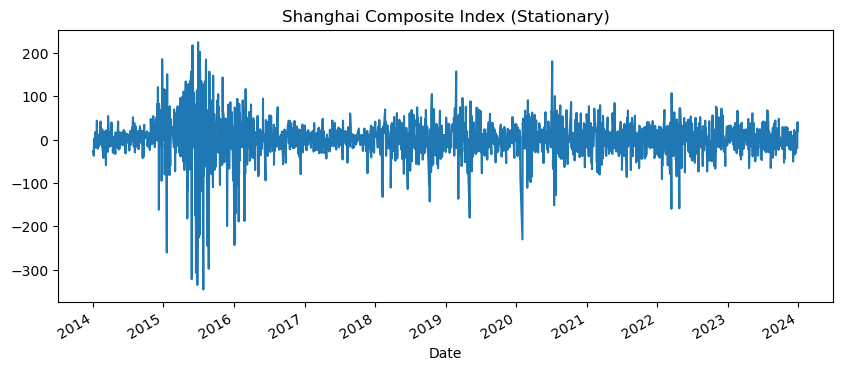

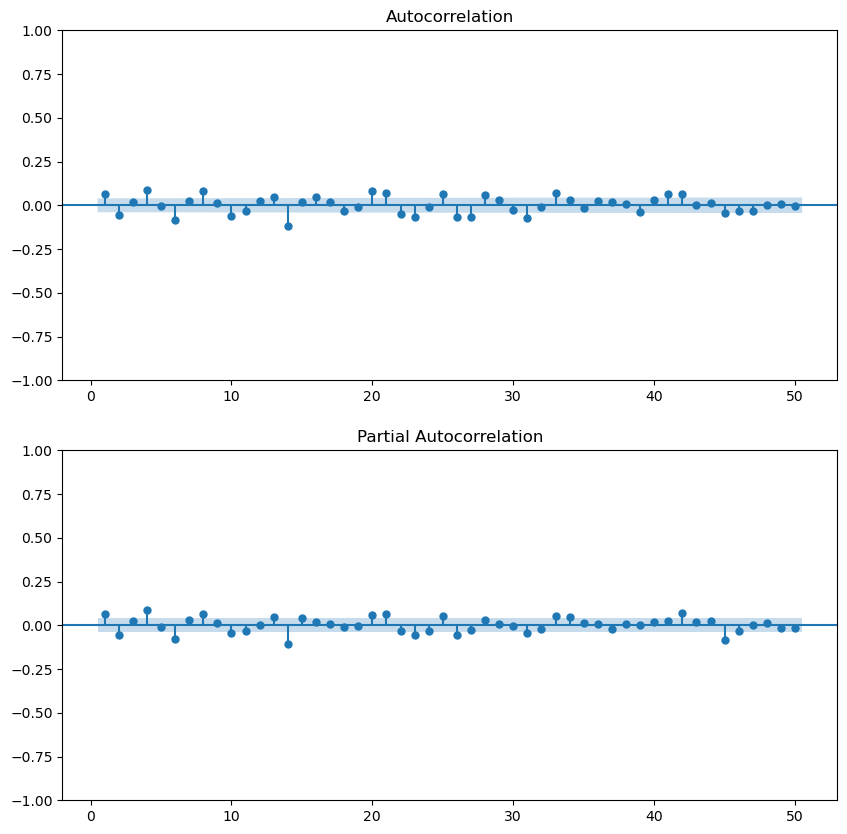

In [9]:
# Plot difference
stationary.plot(figsize=(10,4))
plt.title('Shanghai Composite Index (Stationary)')
plt.show()

# plot ACF & PACF of the stationary dataset
plot_acf_pacf(stationary)

Train: 2187, Test: 244


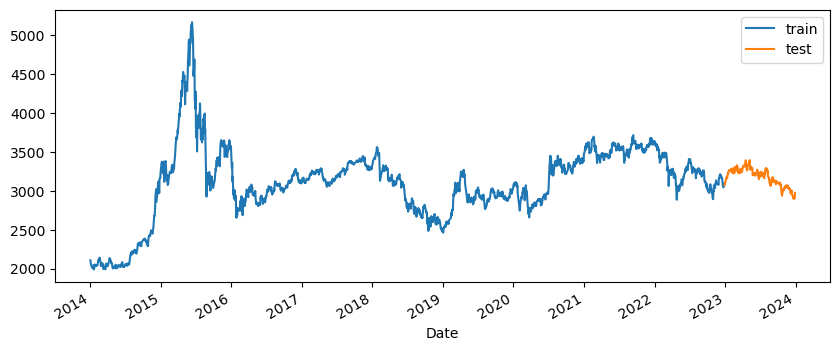

In [10]:
# Define a function for train-test split
def train_test_split(X, size=0.9):
    train = X[:int(X.shape[0]*size)]
    test = X[int(X.shape[0]*size):]
    return train, test

# Split train set and test set
train, test = train_test_split(X=data['Close'], size=0.9)
print(f'Train: {len(train)}, Test: {len(test)}')

# Plot train & test datasets 
fig, ax = plt.subplots(figsize=(10,4))
train.plot(ax=ax, label='train')
test.plot(ax=ax, label='test')
ax.legend()
plt.show()

In [16]:
# Train an ARIMA model using the auto_arima function on the training data
arima_model = auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True)

# Print a summary of the fitted ARIMA model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22799.542, Time=1.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22865.142, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22858.123, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22856.954, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22863.357, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22855.182, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22854.259, Time=0.31 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22779.514, Time=1.44 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22850.379, Time=0.80 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=22781.262, Time=1.55 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22861.508, Time=1.37 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=22839.624, Time=0.47 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=22783.030, Time=1.73 sec
 ARIMA(3,1,2)(0,0,0)[0]  

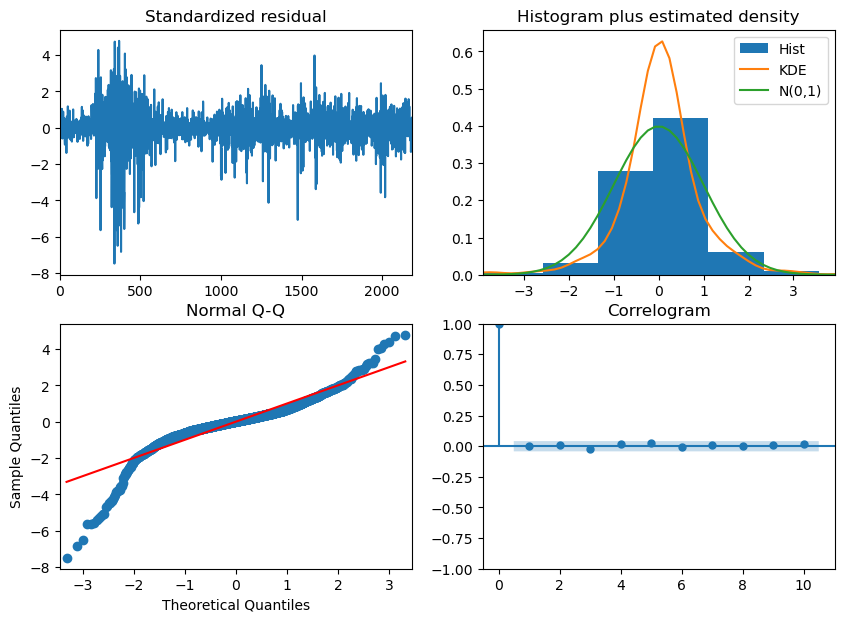

In [13]:
plot_diag = arima_model.plot_diagnostics(figsize=(10,7))

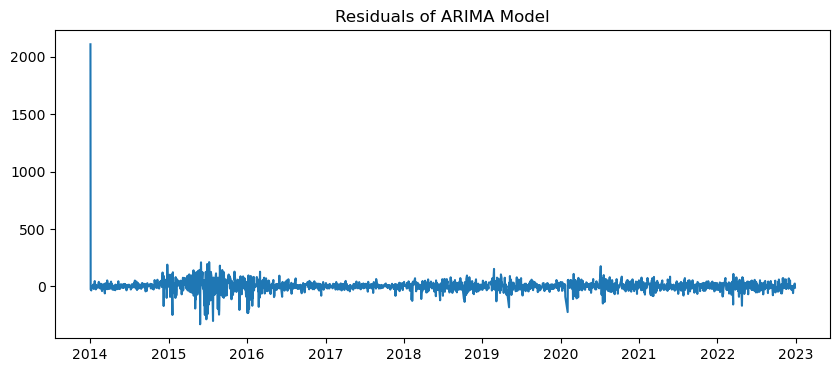

In [109]:
# Extract residuals
arima_residuals = arima_model.resid()

# Plot the residuals
plt.figure(figsize=(10,4))
plt.plot(arima_residuals)
plt.title('Residuals of ARIMA Model')
plt.show()

In [110]:
# Define GARCH model function
def garch_model(data, p=1, o=0, q=1, mean='constant', vol='GARCH', dist='normal'):
    model = arch_model(
        data, 
        p=p, o=o, q=q, 
        mean=mean, 
        vol=vol, 
        dist=dist
    )
    return model

# Apply GARCH model to ARIMA residuals
GARCH = garch_model(arima_residuals)
# Fit the GARCH model
garch_results = GARCH.fit(disp='off', show_warning=False)

# Display GARCH model fitting summary
print(garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -10933.0
Distribution:                  Normal   AIC:                           21874.1
Method:            Maximum Likelihood   BIC:                           21896.8
                                        No. Observations:                 2187
Date:                Sun, Jul 21 2024   Df Residuals:                     2186
Time:                        16:07:25   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.8224      0.602      1.366      0.172 [ -0.357,  2.00

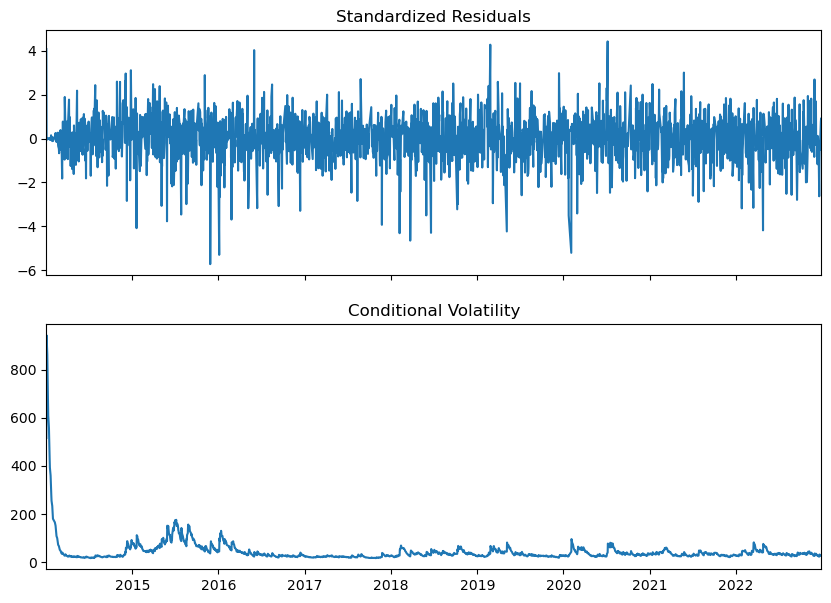

In [111]:
# Plot fitted results
plt.rc("figure", figsize=(10, 7))
garch_results.plot()
plt.show()

In [112]:
# Out-of-sample multi-step-forecast based on auto_arima results
predicted = arima_model.predict(n_periods=len(test))
predicted = pd.DataFrame(predicted, columns=['predicted'])
predicted.index = test.index
predicted

c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,predicted
Date,
2022-12-29,3083.694293
2022-12-30,3084.071017
2023-01-03,3086.807778
2023-01-04,3086.731774
2023-01-05,3084.107575
...,...
2023-12-25,3085.316742
2023-12-26,3085.318184
2023-12-27,3085.324449


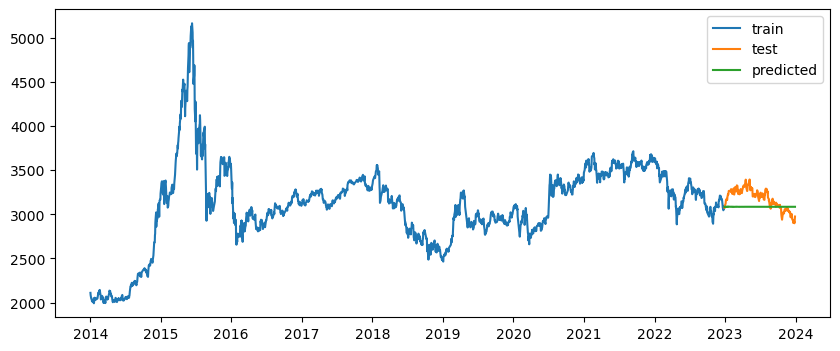

RMSE: 146.50


In [113]:
def plot_train_test(train, test, data):
    # Plot the predictions for validation set
    plt.figure(figsize=(10,4))
    plt.plot(train, label='train')
    plt.plot(test, label='test')
    plt.plot(data, label='predicted')
    plt.legend()
    plt.show()

    # calculate RMSE
    rmse = np.sqrt(mean_squared_error(test, data))
    print(f'RMSE: {rmse:.2f}')

plot_train_test(train, test, predicted)

MAE: 111.46732121912927
RMSE: 127.40580025755936
MAPE: 3.5015449947800934%


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


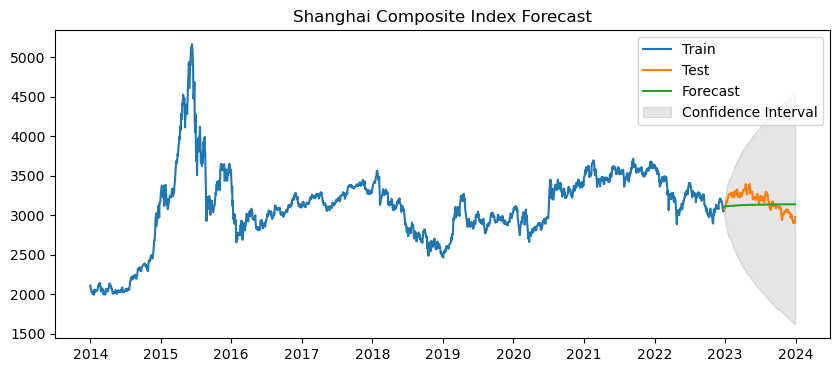

In [114]:
# Forecast with ARIMA Model
n_periods = len(test)
arima_forecast, conf_int = arima_model.predict(n_periods=n_periods, return_conf_int=True)
arima_forecast_series = pd.Series(arima_forecast)
arima_forecast_series.index = test.index
conf_int_df = pd.DataFrame(conf_int, columns=['lower', 'upper'])
conf_int_df.index = test.index

# Apply GARCH Model to Forecast Errors
garch_forecast = garch_results.forecast(horizon=len(test))
garch_forecast_series = pd.Series(garch_forecast.variance.values[-1, :], index=test.index)

# Combine ARIMA and GARCH Forecasts
final_forecast = arima_forecast_series + np.sqrt(garch_forecast_series)

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()


In [115]:
# Function to perform one-step forecast
def one_step_forecast():
    arima_forecast, conf_int = arima_model.predict(n_periods=1, return_conf_int=True)
    garch_forecast = garch_results.forecast(horizon=1)
    return (
        arima_forecast.tolist()[0],
        np.asarray(conf_int).tolist()[0],
        garch_forecast.variance.values[-1, 0] 
    )

arima_predictions = []
confidence_intervals = []
garch_predictions = []

for x in test:
    arima_forecast, conf, garch_forecast = one_step_forecast()
    arima_predictions.append(arima_forecast)
    confidence_intervals.append(conf)
    garch_predictions.append(garch_forecast)

    # Update the ARIMA model
    arima_model.update(x)
    arima_residuals = arima_model.resid()
    # Refit the GARCH model with the updated data
    garch_results = garch_model(arima_residuals)
    garch_results = garch_results.fit(disp="off")


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAE: 29.977704029437017
RMSE: 35.886070225821776
MAPE: 0.9450024943305207%


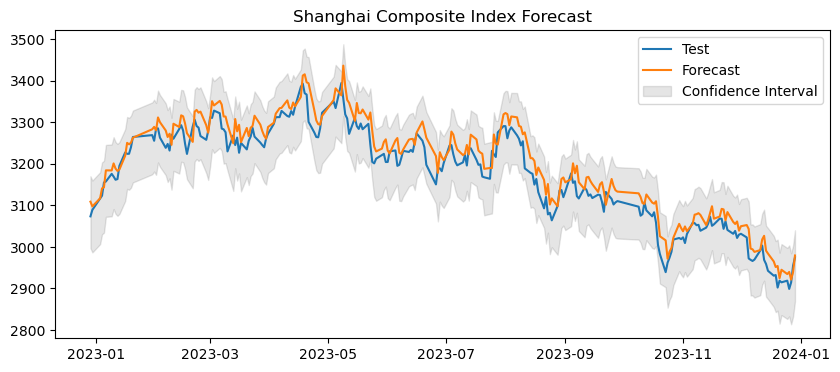

In [116]:
# Combine ARIMA and GARCH Forecasts
arima_forecast_series = pd.Series(arima_predictions, index=test.index)
conf_int_df = pd.DataFrame(confidence_intervals, index=test.index, columns=['lower', 'upper'])
garch_forecast_series = pd.Series(garch_predictions, index=test.index)
final_forecast = arima_forecast_series + np.sqrt(garch_forecast_series)

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()